Building Micrograd - an Autograd engine from Karpathy's "Micrograd" tutorial.

In [17]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [12]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
xs = np.arange(-5, 5, 0.5)
ys = f(xs)

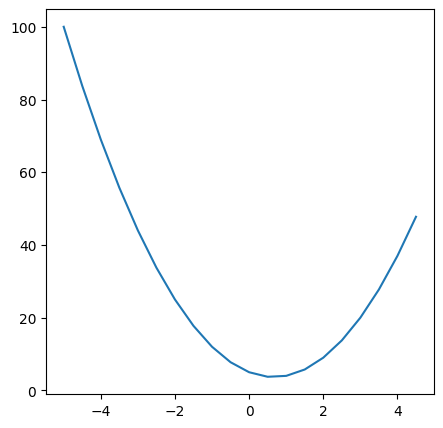

In [4]:
plt.figure(figsize=(5, 5))
plt.plot(xs, ys)

In [5]:
h = 0.00001
x = 2/3
(f(x+h) - f(x))/h

3.0000002482211127e-05

In [6]:
# les get complex hehe
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001
d1 = a*b + c
c += h
d2 = a*b + c

print("d1 is ", d1)
print("d2 is ", d2)

print("slope is ", (d2- d1)/h) 

d1 is  4.0
d2 is  4.0001
slope is  0.9999999999976694


DAY 1 - Done on 5/18/2026 at 19:18 EST

In [2]:
class Value:
    
    def __init__(self, data, _children = (), _op = '', label = ''): # op is string label for the operation that produced a value. 
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # this is a function that will be used to propagate the gradients back to the children.
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        summed = Value(self.data + other.data, (self, other), '+') # this is addition of floats, not of Value objects
        
        def backward():
            self.grad += 1.0 * summed.grad
            other.grad += 1.0 * summed.grad 
        summed._backward = backward 
        return summed
    
    def __mul__(self, other):
        multiplied = Value(self.data * other.data, (self, other), '*') # the second argument stores the two values that are combined to get the result
        def backward():
            self.grad += other.data * multiplied.grad
            other.grad += self.data * multiplied.grad
        multiplied._backward = backward
        return multiplied
    
    # for activation function
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def backward():
            self.grad += (1 - t**2) * out.grad # derivative of tanh is 1 - tanh^2
        out._backward = backward
        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label= 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label= 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
d

Value(data=4.0)

In [5]:
print(d._prev)
d._op

{Value(data=10.0), Value(data=-6.0)}


'+'

In [3]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for each node, we create a label that shows the operation and the data value
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is result of some operation, we create a op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

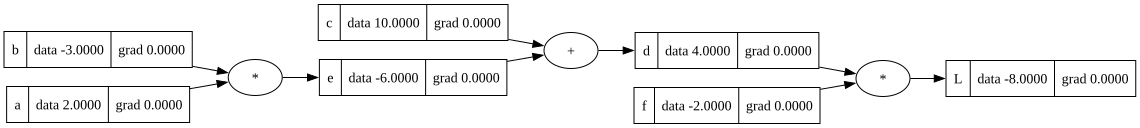

In [7]:
draw_dot(L)

DAY 2 - Done on 5/19/2026 at 18:20 EST 

Starting Day 3 at 15:05 EST on 5/20/2026

d  = c + e

so, dd/dc = 1

dd/de = 1

Now, dL/dc = dL/dd * dd/dc = -2 * 1 = -2

e = a * b
dL/da = dL/de * de/da = -2 * b.data = -2 * -3 = 6

dL/db = dL/de * de/db = -2 * a.data = -2 * 2 = -4

In [8]:
# After writing this, you run the above code again, to see the grad showing up for L. 
# Now, we need to calculate the gradient of L w.r.t other variables (which is usually Loss function w/ weights in NN.)
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
# writing this later
c.grad = -2.0
e.grad = -2.0
# writing this even later
a.grad = 6.0
b.grad = -4.0

In [13]:
def lol():
    h = 0.0001
    a = Value(2.0, label= 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label= 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label= 'a')
    a.data += h
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label= 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    # gradient check
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data 
    
    print((L2 - L1)/h)
lol()

6.000000000021544


In [ ]:
# Backprop ex-2 : through a neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b') 
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# now apply activation function
o = n.tanh(); o.label = 'o'
# tanh reduces n to a value between -1 and 1. 

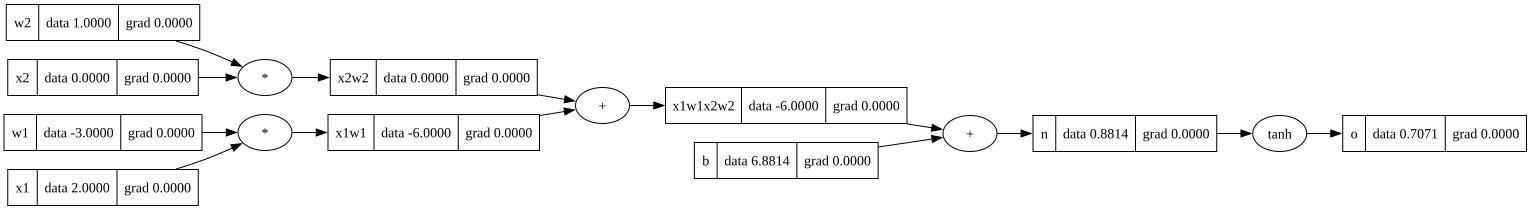

In [33]:
draw_dot(o)

In [16]:
o.grad = 1.0
n.grad = 1 - o.data**2
x1w1x2w2.grad = n.grad * 1.0
b.grad = n.grad * 1.0

# since it's just addition, the gradient of x1w1x2w2 and b is same as n.grad.(Think about it)
x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data # something to notice, since x2 is 0, it's not contributing to the output, so the grad of w2 is also 0.

x1.grad = x1w1.grad * w1.data # here we are finding grad for o w.r.t x1, so we use grad of x1w1 and multiply with w1
w1.grad = x1w1.grad * x1.data

if o = tanh(n)

do/dn = 1 - tanh(n)**2

1 - o.data**2 = 0.499999999

Day 3 - Done on 5/20/2026 at 16:55 EST 

Video time -> (1:09:04)

Starting Day 4 on 5/21/2026 at 16:39 EST

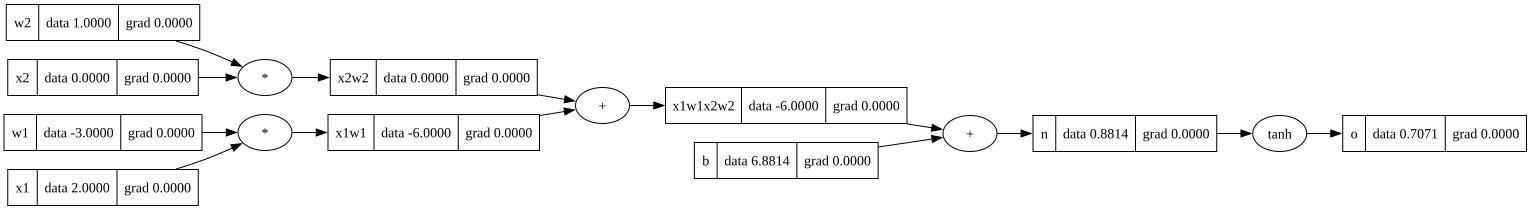

In [34]:
# Going from manual to automatic
# we need backward function for each operation.
draw_dot(o) # run this without above code as a base case.

In [ ]:
o.grad = 1.0
o._backward() # this will call the backward function of o.
# you will see n.grad be 0.5, now....
n._backward() 
# the same n grad will be backpropagated to x1w1x2w2 and b, and then we can call backward on them...
b._backward()
x1w1x2w2._backward()
# since it's an addition, you will see same grads, now going back even further...
x1w1._backward()
x2w2._backward()
# each p._backward() will backpropagate the gradients to its children, and then we can call backward, 
# so you add backward function to all operations that took place between these variables

In [29]:
# but we are still doing this manually, we can automate this by doing a topological sort of the graph(DAG), 
# and then calling backward on each node in the topological order.

# why topological sort? we can only call backward on a node after it's output nodes have been backpropagated. (Added it back to Value class)

In [36]:
o.backward()

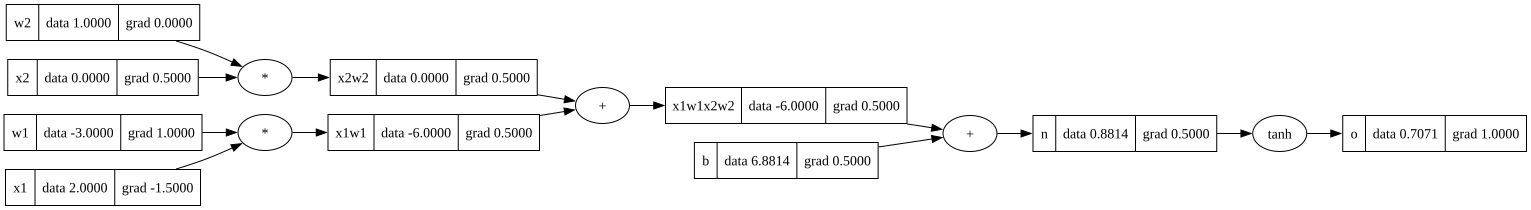

In [37]:
draw_dot(o)

Day 4 - Done on 5/21/2026 at 17:50 EST - video time -> (1:22:40)

Starting Day 5 on 5/22/2026 at 14:25 EST

In [1]:
# There's a bug in our code, which is that we are overwriting the grad of a node when we backpropagate to it
# This happens whenever a variable is used in multiple places.
# To fix this, we need to accumulate the gradients instead of overwriting them.
# so, instead of self.grad = 1.0 * summed.grad, we do self.grad += 1.0 * summed.grad, and same for other operations.

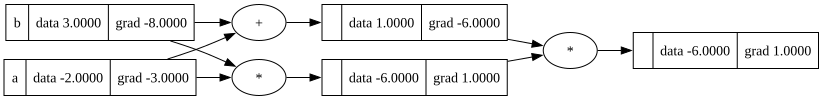

In [4]:
a = Value(-2.0, label= 'a')
b = Value(3.0, label= 'b')
d = a * b; label = 'd'
e = a + b; label = 'e'
f = d * e; label = 'f'
f.backward()

draw_dot(f)

Changing the code to ignore having to write Value every time a new integer we include

In [10]:
a = Value(2.0)
a + 1 # this gives error cause 1.data doesn't exist yet.


Value(data=3.0)

In [16]:
2 * a # this won't work cause python doesn't know 2.__mul__(Value object)
# so we create rmul function - which python checks if 2 * a won't work, will it work for a * 2 (good job python!)

Value(data=4.0)

In [36]:
class Value:
    
    def __init__(self, data, _children = (), _op = '', label = ''): # op is string label for the operation that produced a value. 
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None # this is a function that will be used to propagate the gradients back to the children.
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        summed = Value(self.data + other.data, (self, other), '+') # this is addition of floats, not of Value objects
        
        def backward():
            self.grad += 1.0 * summed.grad
            other.grad += 1.0 * summed.grad 
        summed._backward = backward 
        return summed
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        multiplied = Value(self.data * other.data, (self, other), '*') # the second argument stores the two values that are combined to get the result
        def backward():
            self.grad += other.data * multiplied.grad
            other.grad += self.data * multiplied.grad
        multiplied._backward = backward
        return multiplied
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)) # assert allows us to check if other is int or float, and if not, it will raise an error.
        powered = Value(self.data ** other, (self, ), f"**{other}")
        def backward():
            self.grad += (other * (self.data ** (other - 1))) * powered.grad 
        powered._backward = backward
        return powered
    
    def __rmul__(self, other): # it will reverse the order of multiplication!
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other) 
    
    def __truediv__(self, other):
        return self * (other ** -1) 
    
    # for activation function
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def backward():
            self.grad += (1 - t**2) * out.grad # derivative of tanh is 1 - tanh^2
        out._backward = backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def backward():
            self.grad += (out.data * out.grad)
        out._backward = backward
        return out
    
    def backward(self):
        # topological order all of the children in the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label= 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label= 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
d

Value(data=4.0)

In [34]:
# same code as above
# Backprop ex-2 : through a neuron 
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b') 
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# now apply activation function
o = n.tanh(); o.label = 'o'
# tanh reduces n to a value between -1 and 1. 
o.backward()

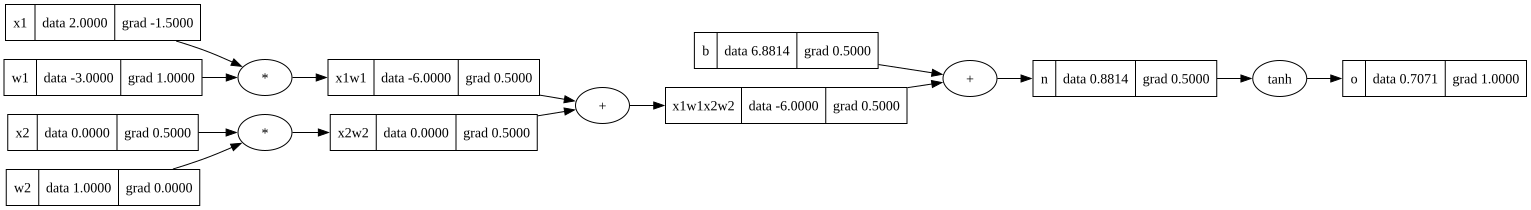

In [35]:
draw_dot(o) 

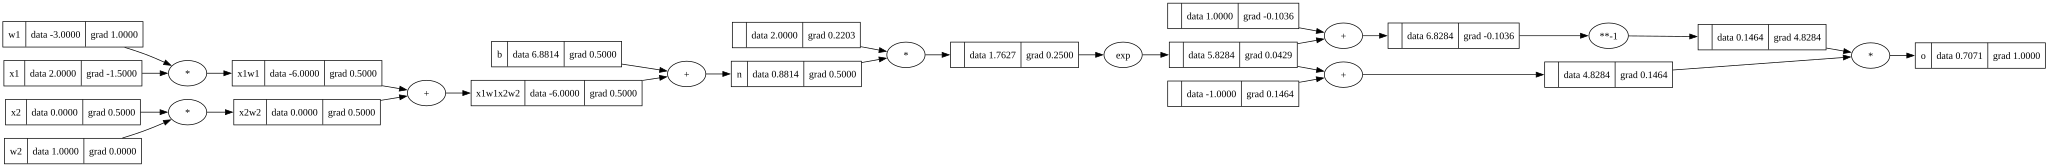

In [38]:
# Now without direct tanh.
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b') 
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# now apply activation function
e = (n*2).exp()
o = (e - 1) / (e + 1)
o.label = 'o'
o.backward()
draw_dot(o)

Day 5 - Done on 5/22/2026 at 16:21 EST - video time -> (1:41:00)

In [1]:
# same thing in pytorch
import torch